In [1]:
import numpy as np
import pandas as pd

In [2]:
seed0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed0_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed0["seed"] = [0 for i in range(len(seed0))]

In [3]:
seed1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed1_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed1["seed"] = [1 for i in range(len(seed1))]

In [4]:
seed2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed2_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed2["seed"] = [2 for i in range(len(seed2))]

In [5]:
seed3 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed3_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed3["seed"] = [3 for i in range(len(seed3))]

In [6]:
seed4 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed4_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed4["seed"] = [4 for i in range(len(seed4))]

In [7]:
seed5 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed5_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed5["seed"] = [5 for i in range(len(seed5))]

In [8]:
seed6 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed6_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed6["seed"] = [6 for i in range(len(seed6))]

In [9]:
seed7 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed7_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed7["seed"] = [7 for i in range(len(seed7))]

In [10]:
seed8 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed8_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed8["seed"] = [8 for i in range(len(seed8))]

In [11]:
seed9 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed9_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed9["seed"] = [9 for i in range(len(seed9))]

In [12]:
df = pd.concat([seed0, seed1, seed2, seed3, seed4, 
                seed5, seed6, seed7, seed8, seed9], ignore_index=True)

In [13]:
import ast

In [14]:
df['positions'] = df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [15]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [16]:
df = df[df["num_edits"] > 0]

In [17]:
df = df[df["URQ_diff"] < 0.0]

In [18]:
len(df)

377

In [19]:
def combine_positions_orientations(row):
    """Turn positions + orientations into set of tuples (start, end, strand)."""
    pos = row["positions"]
    ori = row["orientation"]
    return {(s, e, o) for (s, e), o in zip(pos, ori)}

In [20]:
# Make a new column with motif sets
df["motif_set"] = df.apply(combine_positions_orientations, axis=1)

In [21]:
import itertools

In [22]:
import matplotlib.pyplot as plt

In [23]:
region_cols = ['chrom', 'centered_start', 'centered_end']
region_keys = df[region_cols].drop_duplicates().to_dict('records')

results = []

for region in region_keys:
    region_df = df[
        (df['chrom'] == region['chrom']) &
        (df['centered_start'] == region['centered_start']) &
        (df['centered_end'] == region['centered_end'])
    ]
    
    seed_to_sites = {row['seed']: row['motif_set'] for _, row in region_df.iterrows()}

    for seed1, seed2 in itertools.combinations(sorted(seed_to_sites.keys()), 2):
        set1 = seed_to_sites[seed1]
        set2 = seed_to_sites[seed2]
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        jaccard = intersection / union if union > 0 else float('nan')
        results.append({
            **region,
            'seed1': seed1,
            'seed2': seed2,
            'jaccard': jaccard
        })

jaccard_df = pd.DataFrame(results)

In [24]:
avg_jaccard_df = (
    jaccard_df
    .groupby(["chrom", "centered_start", "centered_end"])["jaccard"]
    .mean()
    .reset_index()
    .rename(columns={"jaccard": "avg_jaccard"})
)

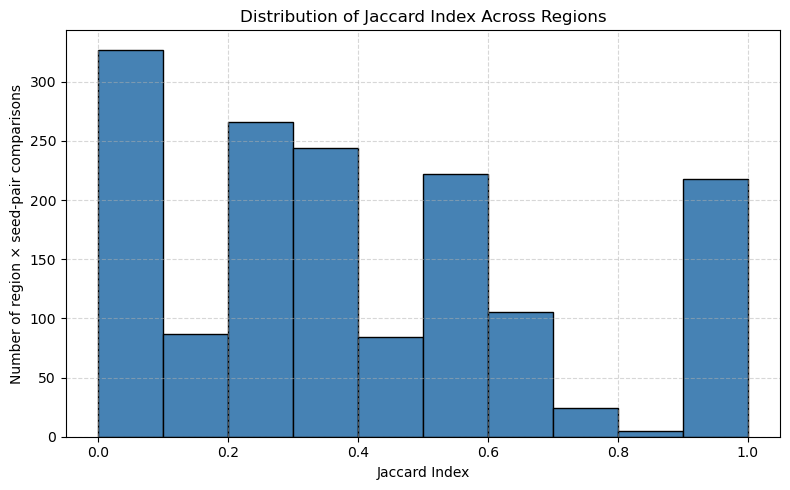

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(jaccard_df['jaccard'].dropna(), bins=10, color='steelblue', edgecolor='black')
plt.xlabel('Jaccard Index')
plt.ylabel('Number of region × seed-pair comparisons')
plt.title('Distribution of Jaccard Index Across Regions')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

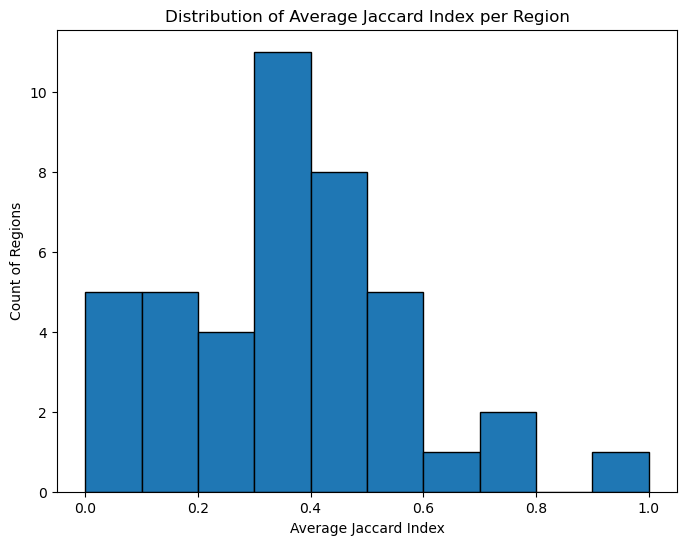

In [28]:
plt.figure(figsize=(8,6))
plt.hist(avg_jaccard_df["avg_jaccard"], bins=10, edgecolor="black")

plt.title("Distribution of Average Jaccard Index per Region")
plt.xlabel("Average Jaccard Index")
plt.ylabel("Count of Regions")
plt.show()

In [29]:
import random

region_keys = df[['chrom', 'centered_start', 'centered_end']].drop_duplicates()
random_regions = region_keys.sample(5, random_state=40).to_dict('records')

In [30]:
def get_jaccard_matrix_from_df(region, jaccard_df):
    region_mask = (
        (jaccard_df['chrom'] == region['chrom']) &
        (jaccard_df['centered_start'] == region['centered_start']) &
        (jaccard_df['centered_end'] == region['centered_end'])
    )
    sub_df = jaccard_df[region_mask]
    seeds = sorted(set(sub_df['seed1']) | set(sub_df['seed2']))
    matrix = pd.DataFrame(np.eye(len(seeds)), index=seeds, columns=seeds)

    for _, row in sub_df.iterrows():
        s1, s2 = row['seed1'], row['seed2']
        matrix.loc[s1, s2] = row['jaccard']
        matrix.loc[s2, s1] = row['jaccard']  # symmetric

    return matrix

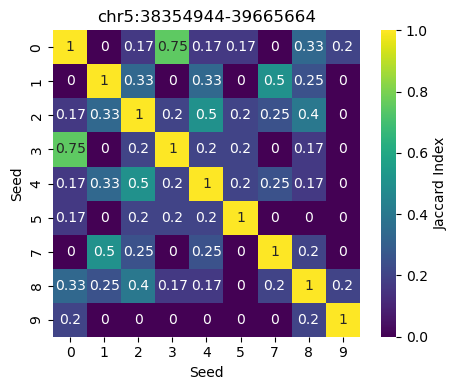

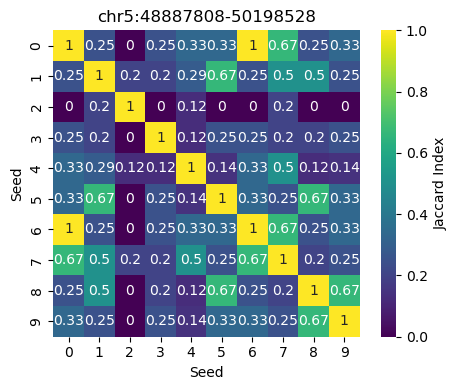

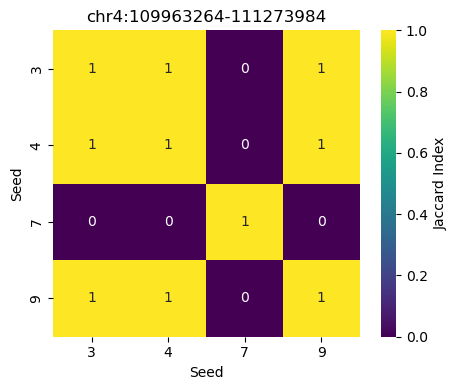

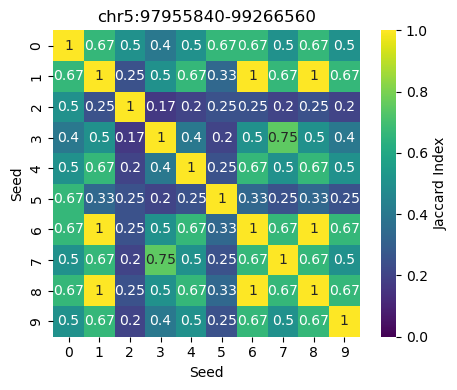

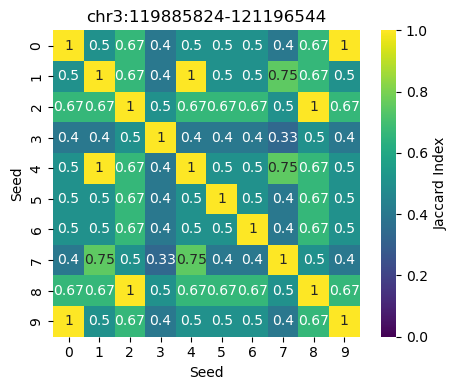

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

for region in random_regions:
    mat = get_jaccard_matrix_from_df(region, jaccard_df)

    plt.figure(figsize=(5, 4))
    sns.heatmap(mat, annot=True, cmap='viridis', vmin=0, vmax=1, square=True,
                xticklabels=mat.columns, yticklabels=mat.index,
                cbar_kws={'label': 'Jaccard Index'})
    plt.title(f"{region['chrom']}:{region['centered_start']}-{region['centered_end']}")
    plt.xlabel("Seed")
    plt.ylabel("Seed")
    plt.tight_layout()
    plt.show()

In [32]:
# collecting all CTCFs

import pandas as pd

bin_size = 2048
center_offset = 320 * bin_size
motif_len = 19

In [33]:
ctcf_records = []

for idx, row in df.iterrows():
    chrom = row['chrom']
    win_start = row['centered_start']
    win_end = row['centered_end']
    seed = row['seed']
    ctcf_sites = row['positions']
    orientations = list(row['orientation']) if isinstance(row['orientation'], str) else []

    if isinstance(ctcf_sites, str):
        try:
            ctcf_sites = eval(ctcf_sites)
        except:
            continue

    for i, (rel_start, rel_end) in enumerate(ctcf_sites):
        orientation = orientations[i] if i < len(orientations) else '?'
        ctcf_records.append({
            'chrom': chrom,
            'centered_start': win_start,
            'centered_end': win_end,
            'rel_start': rel_start,
            'rel_end': rel_end,
            'orientation': orientation,
            'seed': seed
        })

ctcf_df = pd.DataFrame(ctcf_records)


In [34]:
len(ctcf_df)

938

In [35]:
from tqdm import tqdm

In [36]:
# Count number of unique seeds in which each site appears
ctcf_seed_counts = (
    ctcf_df
    .groupby(['chrom', 'centered_start', 'centered_end', 'rel_start', 'rel_end', 'orientation'])
    .agg(seeds_present=('seed', 'nunique'))
    .reset_index()
)

In [37]:
ctcf_seed_counts['fraction_across_seeds'] = ctcf_seed_counts['seeds_present'] / 10

In [38]:
ctcf_seed_counts['genomic_start'] = ctcf_seed_counts['centered_start'] + center_offset + ctcf_seed_counts['rel_start']
ctcf_seed_counts['genomic_end'] = ctcf_seed_counts['centered_start'] + center_offset + ctcf_seed_counts['rel_end']

In [39]:
from pyfaidx import Fasta

In [40]:
from tqdm import tqdm

In [41]:
fasta_file = "/project2/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [42]:
def get_sequence(genome, chrom, start, end):
    seq = genome[chrom][start:end].seq.upper()
    return seq

In [43]:
def reverse_complement(seq: str) -> str:
    complement = str.maketrans("ACGTN", "TGCAN")  # include N if needed
    return seq.translate(complement)[::-1]

In [44]:
# estimating background probabilities

from collections import Counter

# Initialize counter
total_counts = Counter()
total_bases = 0

for _, row in avg_jaccard_df.iterrows():
    # read sequence from genome
    seq = get_sequence(genome, row["chrom"], row["centered_start"], row["centered_end"])
    seq = seq.upper()
    
    # count nucleotides in this sequence
    counts = Counter(seq)
    
    # keep only A/C/G/T
    for b in "ACGT":
        total_counts[b] += counts.get(b, 0)
    
    # accumulate total base count
    total_bases += sum(counts[b] for b in "ACGT")

# calculate background probabilities
bg_probs = {b: total_counts[b] / total_bases for b in "ACGT"}
print("Estimated background probabilities:", bg_probs)

Estimated background probabilities: {'A': 0.29268879286791105, 'C': 0.20697288889154505, 'G': 0.20722222477544558, 'T': 0.2931160934650983}


In [45]:
collected_ctcfs = []

for _, row in tqdm(ctcf_seed_counts.iterrows(), total=len(ctcf_seed_counts)):
    chrom = row["chrom"]
    genomic_start = row["genomic_start"]
    genomic_end = row["genomic_end"]
    orientation = row["orientation"]
    
    ctcf_seq = get_sequence(genome, chrom, genomic_start, genomic_end)
    
    if orientation == "-":
        ctcf_seq = reverse_complement(ctcf_seq)
        
    collected_ctcfs.append(ctcf_seq)

100%|██████████| 367/367 [00:00<00:00, 31602.81it/s]


In [ ]:
# # Background frequency
# bg = 0.25  

# def seq_score(seq, pwm, bg=0.25, pseudocount=1e-9):
#     base_idx = {'A':0, 'C':1, 'G':2, 'T':3}
#     score = 0.0
#     seq = seq.upper()
    
#     for i, b in enumerate(seq):
#         if b not in base_idx:
#             continue  # skip Ns or unexpected bases
#         p = pwm[i, base_idx[b]]
#         # add pseudocount to avoid division by zero
#         p = max(p, pseudocount)
#         score += np.log2(p / bg)
#     return score

In [46]:
def seq_score(seq, pwm, bg=None, pseudocount=1e-9):
    """
    seq: DNA sequence (string)
    pwm: numpy array of shape (length, 4)
    bg: dict of background probabilities, e.g., {'A':0.29, 'C':0.21, 'G':0.21, 'T':0.29}
    pseudocount: small value to avoid log(0)
    """
    if bg is None:
        bg = {'A':0.25, 'C':0.25, 'G':0.25, 'T':0.25}

    base_idx = {'A':0, 'C':1, 'G':2, 'T':3}
    score = 0.0
    seq = seq.upper()
    
    for i, b in enumerate(seq):
        if b not in base_idx:
            continue  # skip Ns or unexpected bases
        p = pwm[i, base_idx[b]]
        p = max(p, pseudocount)
        score += np.log2(p / bg[b])  # use bg for this base
    return score

In [47]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [48]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [49]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)

In [50]:
scores = [seq_score(ctcf, pwm_CTCF, bg=bg_probs) for ctcf in collected_ctcfs]

In [51]:
ctcf_seed_counts["score"] = scores

In [ ]:
ctcf_seed_counts

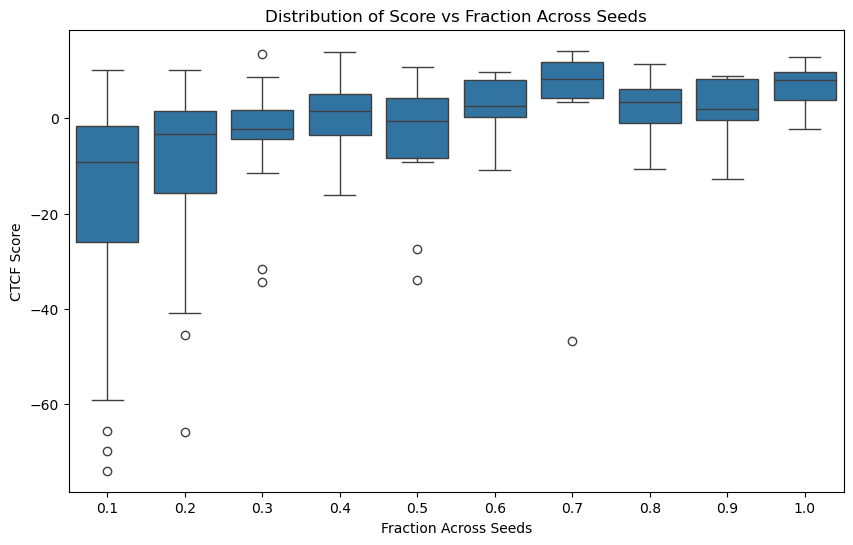

In [52]:
plt.figure(figsize=(10,6))
sns.boxplot(x="fraction_across_seeds", y="score", data=ctcf_seed_counts)
plt.xlabel("Fraction Across Seeds")
plt.ylabel("CTCF Score")
plt.title("Distribution of Score vs Fraction Across Seeds")
plt.show()

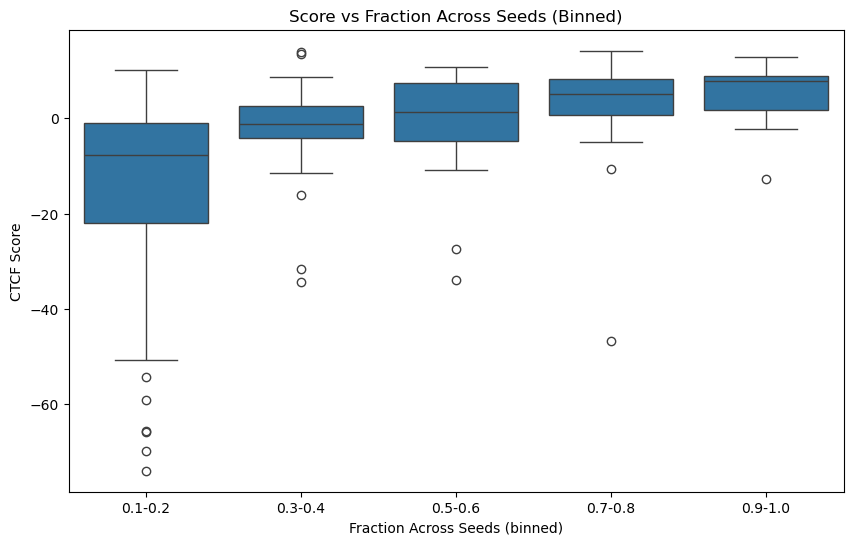

/tmp/SLURM_1823719/ipykernel_1008722/4145730041.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_scores = ctcf_seed_counts.groupby("fraction_bin")["score"].mean().reset_index()


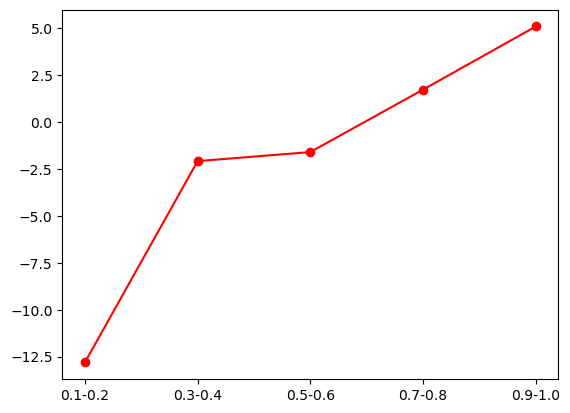

In [53]:
# define bins and labels
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  # edges of bins
labels = ["0.1-0.2", "0.3-0.4", "0.5-0.6", "0.7-0.8", "0.9-1.0"]

# create a new binned column
ctcf_seed_counts["fraction_bin"] = pd.cut(ctcf_seed_counts["fraction_across_seeds"], bins=bins, labels=labels)

# boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x="fraction_bin", y="score", data=ctcf_seed_counts)
plt.xlabel("Fraction Across Seeds (binned)")
plt.ylabel("CTCF Score")
plt.title("Score vs Fraction Across Seeds (Binned)")
plt.show()

# optional: plot mean trend line on top
mean_scores = ctcf_seed_counts.groupby("fraction_bin")["score"].mean().reset_index()
plt.plot(mean_scores["fraction_bin"], mean_scores["score"], marker='o', color='red')

In [54]:
len(ctcf_seed_counts)

367

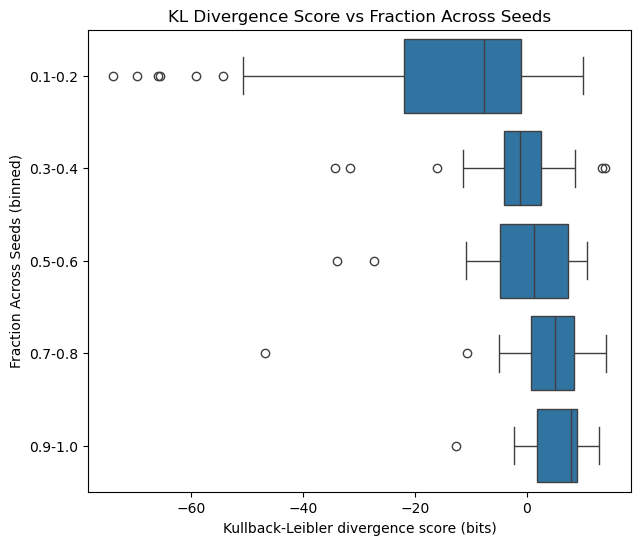

/tmp/SLURM_1823719/ipykernel_1008722/2480002461.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_scores = ctcf_seed_counts.groupby("fraction_bin")["score"].mean().reset_index()


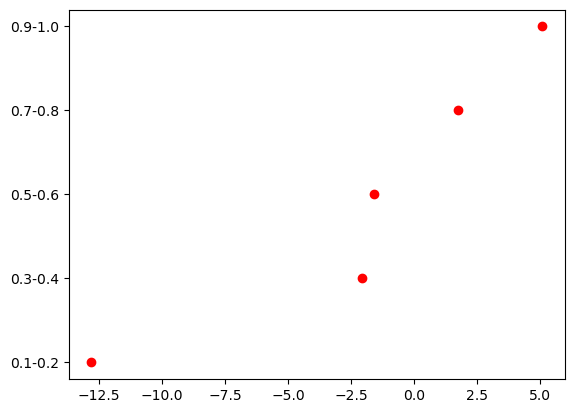

In [55]:
plt.figure(figsize=(7,6))
sns.boxplot(
    y="fraction_bin", 
    x="score", 
    data=ctcf_seed_counts,
    orient="h"
)

plt.ylabel("Fraction Across Seeds (binned)")
plt.xlabel("Kullback-Leibler divergence score (bits)")
plt.title("KL Divergence Score vs Fraction Across Seeds")
plt.show()

# optional: overlay mean trend line
mean_scores = ctcf_seed_counts.groupby("fraction_bin")["score"].mean().reset_index()
plt.plot(mean_scores["score"], mean_scores["fraction_bin"], marker='o', color='red', linestyle='')

In [56]:
sum_scores_df = (
    ctcf_seed_counts
    .groupby(["chrom", "centered_start", "centered_end"])["score"]
    .sum()
    .reset_index()
    .rename(columns={"score": "sum_score"})
)

In [57]:
merged_df = jaccard_df.merge(
    sum_scores_df, 
    on=["chrom", "centered_start", "centered_end"],
    how="inner"
)

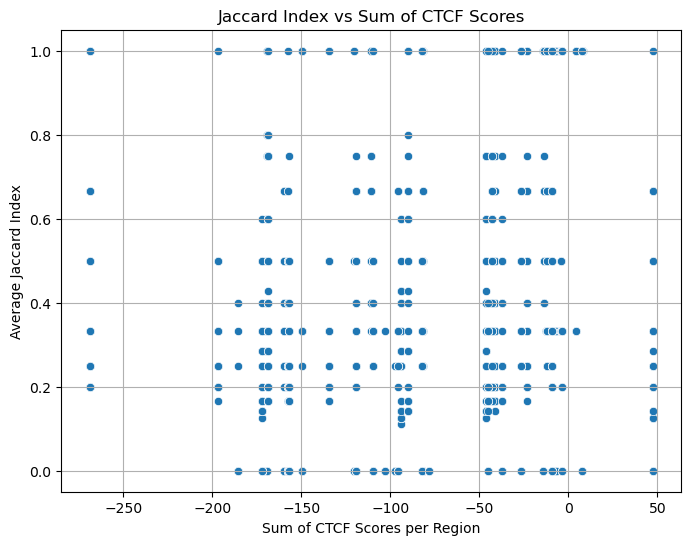

In [58]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="sum_score", y="jaccard", data=merged_df)
plt.xlabel("Sum of CTCF Scores per Region")
plt.ylabel("Average Jaccard Index")
plt.title("Jaccard Index vs Sum of CTCF Scores")
plt.grid(True)
plt.show()

In [59]:
# Define bins and labels
bins = np.linspace(0, 1, 6)  # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

# Create a new binned column
merged_df["jaccard_bin"] = pd.cut(merged_df["jaccard"], bins=bins, labels=labels, include_lowest=True)

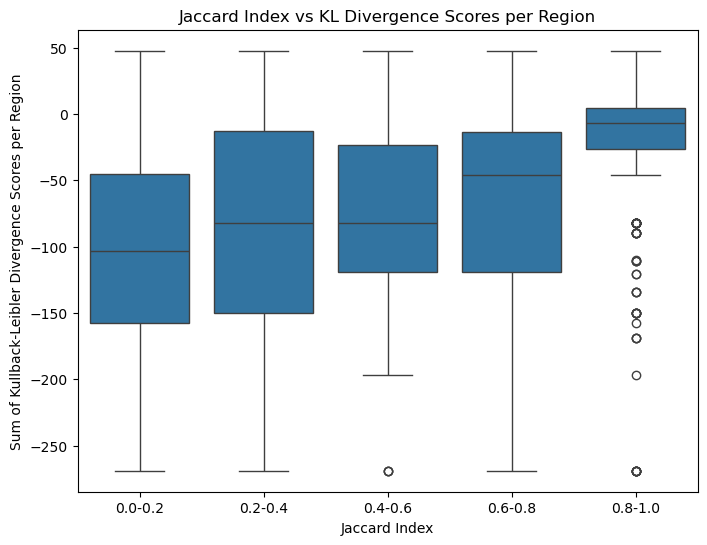

In [60]:
# Boxplot: one box per Jaccard bin
plt.figure(figsize=(8,6))
sns.boxplot(x="jaccard_bin", y="sum_score", data=merged_df)
plt.xlabel("Jaccard Index")
plt.ylabel("Sum of Kullback-Leibler Divergence Scores per Region")
plt.title("Jaccard Index vs KL Divergence Scores per Region")
plt.show()

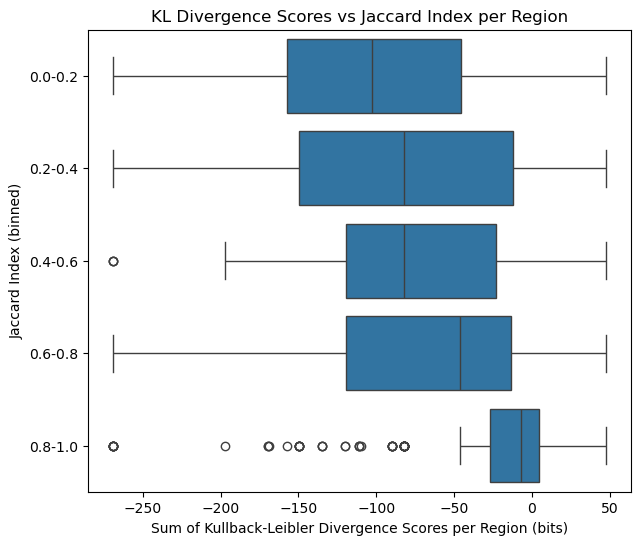

In [61]:
plt.figure(figsize=(7,6))
sns.boxplot(
    x="sum_score", 
    y="jaccard_bin", 
    data=merged_df,
    orient="h"
)
plt.xlabel("Sum of Kullback-Leibler Divergence Scores per Region (bits)")
plt.ylabel("Jaccard Index (binned)")
plt.title("KL Divergence Scores vs Jaccard Index per Region")
plt.show()

In [63]:
from scipy.stats import pearsonr

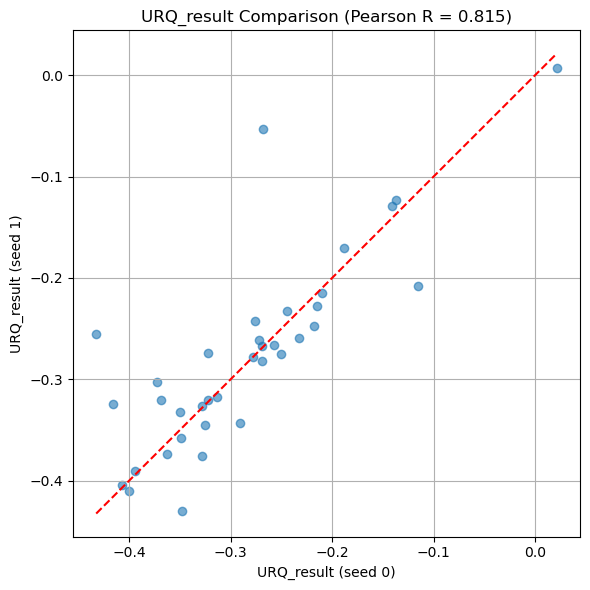

In [64]:
# Pivot to align seed 0 and seed 1 by region
pivot_df = df[df['seed'].isin([0, 1])].pivot_table(
    index=['chrom', 'centered_start', 'centered_end'], 
    columns='seed', 
    values='URQ_result'
).dropna()

pivot_df.columns = ['seed0', 'seed1']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed0'], pivot_df['seed1'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed0'], pivot_df['seed1'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_result (seed 0)')
plt.ylabel('URQ_result (seed 1)')
plt.title(f'URQ_result Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

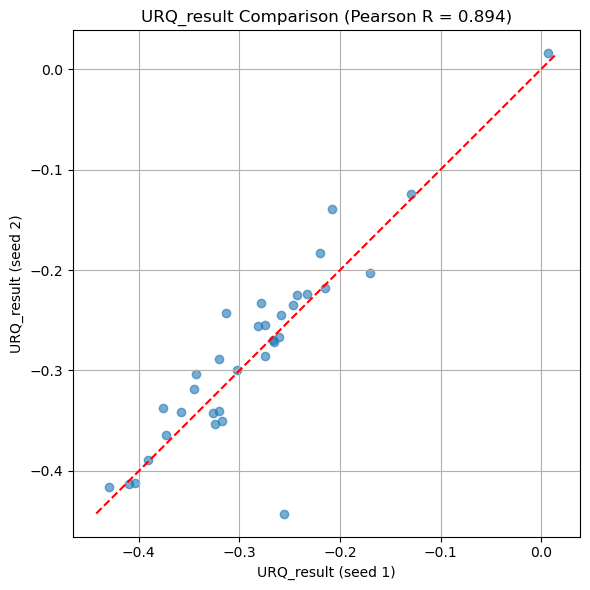

In [65]:
# Pivot to align seed 1 and seed 2 by region
pivot_df = df[df['seed'].isin([1, 2])].pivot_table(
    index=['chrom', 'centered_start', 'centered_end'], 
    columns='seed', 
    values='URQ_result'
).dropna()

pivot_df.columns = ['seed1', 'seed2']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed1'], pivot_df['seed2'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed1'], pivot_df['seed2'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_result (seed 1)')
plt.ylabel('URQ_result (seed 2)')
plt.title(f'URQ_result Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

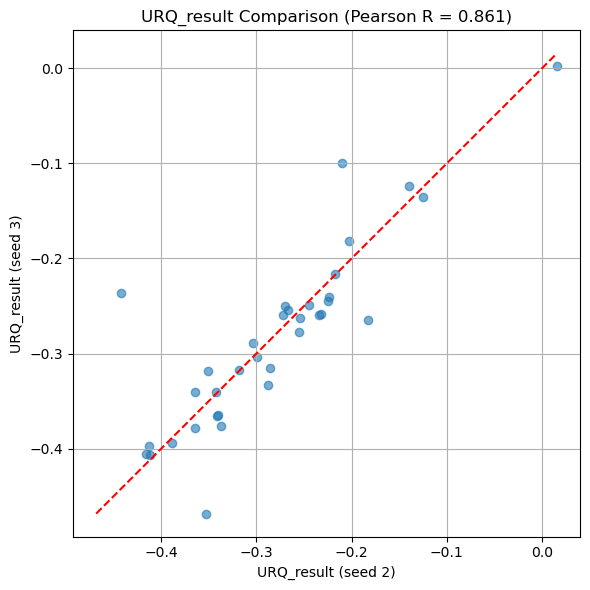

In [66]:
# Pivot to align seed 2 and seed 3 by region
pivot_df = df[df['seed'].isin([2, 3])].pivot_table(
    index=['chrom', 'centered_start', 'centered_end'], 
    columns='seed', 
    values='URQ_result'
).dropna()

pivot_df.columns = ['seed2', 'seed3']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed2'], pivot_df['seed3'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed2'], pivot_df['seed3'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_result (seed 2)')
plt.ylabel('URQ_result (seed 3)')
plt.title(f'URQ_result Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
region_cols = ['chrom', 'centered_start', 'centered_end']
aligned_df = df.pivot_table(index=region_cols, columns='seed', values=['orientation', 'positions'], aggfunc='first')
aligned_df = aligned_df.dropna()  # keep only complete pairs

In [ ]:
# aligned_df

In [75]:
region = ('chr5', 38354944, 39665664)
region_df = df[
    (df['chrom'] == region[0]) &
    (df['centered_start'] == region[1]) &
    (df['centered_end'] == region[2])]

In [98]:
len(region_df)

9

In [81]:
from matplotlib.patches import FancyArrow, Patch, Rectangle
import ast

In [88]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.ndimage import gaussian_filter1d

In [92]:
# --- Parse positions ---
region_df['positions'] = region_df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# --- Parameters ---
region_length = 2048
flank = 60
total_length = region_length + 2 * flank
bins = np.arange(-flank, region_length + flank + 1, 10)  # 10 bp resolution

# --- Build numeric orientation tracks for each seed ---
tracks = []
seed_ids = []

for seed in sorted(region_df['seed'].unique()):
    row = region_df[region_df['seed'] == seed].iloc[0]
    signal = np.zeros(len(bins))
    for (start, end), ori in zip(row['positions'], row['orientation']):
        # Clip to within flanked region
        start = max(-flank, min(start, region_length + flank))
        pos_idx = np.argmin(np.abs(bins - start))
        signal[pos_idx] = 1 if ori == '+' else -1
    # Smooth a bit to tolerate small positional shifts
    signal = gaussian_filter1d(signal, sigma=1)
    tracks.append(signal)
    seed_ids.append(seed)

tracks = np.array(tracks)

# --- Cluster by spatial similarity ---
dist = pdist(tracks, metric='cosine')
link = linkage(dist, method='average')
cluster_order = leaves_list(link)
seed_order = [seed_ids[i] for i in cluster_order]

/tmp/SLURM_1823719/ipykernel_1008722/2677005341.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['positions'] = region_df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


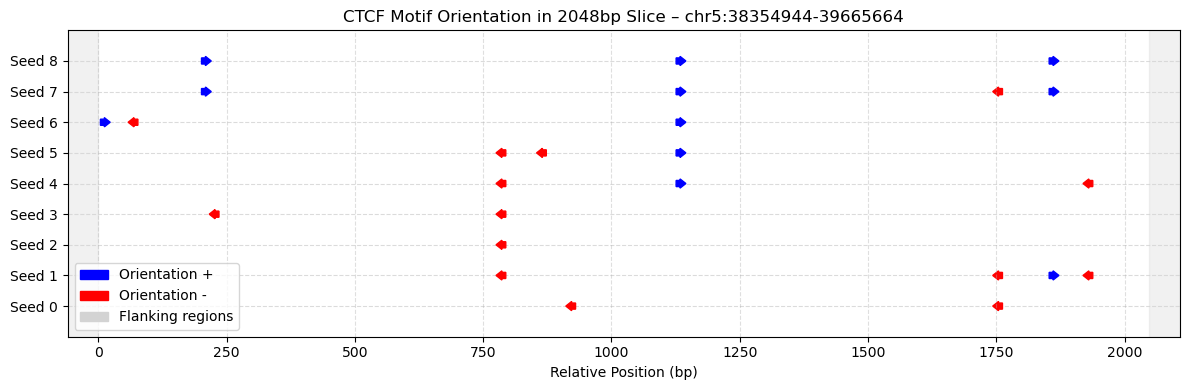

In [99]:
# --- Plot setup ---
fig, ax = plt.subplots(figsize=(12, 4))  # taller for more rows
y_positions = {seed: idx for idx, seed in enumerate(seed_order)}  # top-down: 5 → 0

# --- Draw grey flanks ---
ax.add_patch(Rectangle((-60, -1), 60, len(seed_order) + 1, color='lightgrey', alpha=0.3, zorder=0))
ax.add_patch(Rectangle((2048, -1), 60, len(seed_order) + 1, color='lightgrey', alpha=0.3, zorder=0))

# --- Dashed baseline for each row ---
for seed in seed_order:
    y = y_positions[seed]
    ax.plot([-flank, region_length + flank], [y, y],
            color='lightgrey', linewidth=0.8, linestyle='--', alpha=0.8, zorder=1)

# --- Draw motifs ---
for _, row in region_df.iterrows():
    seed = row['seed']
    y = y_positions[seed]
    positions = row['positions']
    orientations = row['orientation']
    
    for (start, end), ori in zip(positions, orientations):
        color = 'blue' if ori == '+' else 'red'
        direction = 1 if ori == '+' else -1
        width = end - start
        arrow = FancyArrow(start, y, width * direction, 0,
                           width=0.2,
                           head_width=0.3,
                           head_length=min(20, width * 0.6),
                           length_includes_head=True,
                           color=color)
        ax.add_patch(arrow)

# --- Axis settings ---
ax.set_xlim(-60, 2108)
ax.set_ylim(-1, len(seed_order))
ax.set_yticks([y_positions[s] for s in seed_order])
ax.set_yticklabels([f'Seed {s}' for s in [i for i in range(9)]])
ax.set_xlabel('Relative Position (bp)')
ax.set_title(f"CTCF Motif Orientation in 2048bp Slice – {region[0]}:{region[1]}-{region[2]}")
ax.grid(axis='x', linestyle='--', alpha=0.4)

# --- Legend ---
legend_handles = [
    Patch(color='blue', label='Orientation +'),
    Patch(color='red', label='Orientation -'),
    Patch(color='lightgrey', label='Flanking regions')
]

ax.legend(handles=legend_handles, loc='lower left')

plt.tight_layout()

# --- Save as SVG ---
# plt.savefig("ctcf_seeds_orientations.svg", format="svg", bbox_inches="tight")

plt.show()


### Check underlying sequence

In [ ]:
# df

In [100]:
chrom = "chr5"
start = 38354944
end = 39665664	

In [101]:
path_to_ohe_seq = f"/scratch1/smaruj/generate_genomic_boundary/ohe_X/fold0/{chrom}_{start}_{end}_X.pt"

In [102]:
import torch

In [103]:
ohe = torch.load(path_to_ohe_seq)

/tmp/SLURM_1823719/ipykernel_1008722/1069704943.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ohe = torch.load(path_to_ohe_seq)


In [104]:
central_bin = 256
cropping = 64
bins_size = 2048

In [105]:
scanned_slice_start = ((central_bin + cropping) * bins_size)

In [106]:
scanned_slice_end = ((central_bin + cropping + 1) * bins_size)

In [107]:
ohe_slice = ohe[:, :, scanned_slice_start:scanned_slice_end]

In [112]:
for element in region_df["positions"]:
    print(element)

[(201, 220), (1126, 1145), (1762, 1781), (1853, 1872)]
[(794, 813)]
[(794, 813), (1126, 1145), (1938, 1957)]
[(201, 220), (1126, 1145), (1853, 1872)]
[(794, 813), (873, 892), (1126, 1145)]
[(4, 23), (77, 96), (1126, 1145)]
[(235, 254), (794, 813)]
[(794, 813), (1762, 1781), (1853, 1872), (1938, 1957)]
[(930, 949), (1762, 1781)]


In [117]:
# check_for_ctcf = ohe_slice[0, :, 794:813]
check_for_ctcf = ohe_slice[0, :, 1126:1145]

check_for_ctcf_np = check_for_ctcf.numpy()

In [118]:
def decode_ohe_dna(ohe_array, reverse_complement=False):
    """
    Decode a one-hot encoded DNA array (shape: 4 x seq_len) into a string.
    If reverse_complement=True, returns the reverse complement of the sequence.
    """
    # Map from channel index to base
    index_to_base = ['A', 'C', 'G', 'T']
    
    # Decode from one-hot
    base_indices = np.argmax(ohe_array, axis=0)
    sequence = ''.join(index_to_base[i] for i in base_indices)
    
    if reverse_complement:
        # Define complement map
        complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
        sequence = ''.join(complement[base] for base in reversed(sequence))
    
    return sequence

In [119]:
# decoded = decode_ohe_dna(check_for_ctcf_np, reverse_complement=True)
decoded = decode_ohe_dna(check_for_ctcf_np, reverse_complement=False)

In [120]:
decoded_sequence = ''.join(decoded)
print(decoded_sequence)

TATCCCTCAGAGGGCAGCA
